# Demo — fine-tuning PARNET on spliceosome data (HepG2)

## Set-up

### Imports

In [1]:
import pylbsr.notebooks
import pylbsr.misc

import functools
import torch
import torch.utils.data
import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger
from dotmap import DotMap
from pathlib import Path
import pandas as pd
import yaml
from typing import Literal

import parnet
from parnet.layers import (
    AdditiveMix,
    LinearProjectionHead,
    MixCoeffMLP,
    MixCoeffPenalty,
    NewAdditiveMix,
    LinearProjection,
    NewMixCoeffMLP,
    NewMixCoeffPenalty,
)
from parnet.losses import MultinomialNLLLoss
from parnet.bin.train import LightningModel
from parnet_additional_utils import (
    load_parnet_model,
    load_parnet_model_from_statedict,
    ParnetModelName,
    save_parnet_model_as_statedict,
    GzListDataset,
    HFDSDataset,
)
from parnet.utils import count_trainable_params

/home/lhofer/pixi-envs/parnet--unified-7433550039317049837/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


### Initialization

In [2]:
_notebook_name = "train_from_pretrained.py.ipynb"
_notebook_path = f"notebooks/explore/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)

logger = pylbsr.misc.init_logger(_notebook_name)

PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[14:45:39] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [3]:
# NOTE : THIS CELL MIGHT REQUIRE MANUAL ADJUSTMENT FOR THE GPU TO USE.

pylbsr.misc.set_seed(42)

torch.use_deterministic_algorithms(
    False
)  # some backbone ops (dilated convs) have no deterministic CUDA kernel

params_gpu_index = 0

device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

# Print GPUs information to verify the correct GPU is being used
if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[14:45:39] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.14 s (00:00:00)


### Parameters

In [4]:
# ── Task / data configuration ──────────────────────────────────────────────────
params_num_tasks = 9  # number of spliceosome RBPs selected in prepare_datasets
params_seq_length = 600  # model window length; GzListDataset re-pads stripped sequences to this

# Dataset source format: "pt"   uses GzListDataset (output of prepare_datasets.py.ipynb)
#                        "hfds" uses HFDSDataset    (run scripts/convert_pt_to_hfds.py first)
params_dataset_format: Literal["pt", "hfds"] = "pt"

# Validation split name in the dataset file.
# Use "validation" for .pt files produced by convert_hfds_to_pt.py before the split
# normalisation fix (output of that script now always writes "valid").
params_valid_split: str = "valid"

# ── Training strategy ─────────────────────────────────────────────

# We start from a specific pretrained parnet model so as to speed-up the training process.
pretrained_model_name = ParnetModelName.PARNET_7M_0_0

# Which head architecture to attach after resetting the pretrained head (see section below).
# Options:
#   "additive_mix"     — AdditiveMix, standard logsumexp (use_maximum_target_control_logprob=False)
#   "additive_mix_max" — AdditiveMix, max-stabilised logprob (use_maximum_target_control_logprob=True)
#                        RECOMMENDED: consistent with 7M / 21M pretrained training settings
#   "new_additive_mix" — NewAdditiveMix (experimental; control_nograd not functional in forward)
params_head_variant: Literal["additive_mix", "additive_mix_max", "new_additive_mix"] = (
    "additive_mix_max"
)

# Which finetuning strategy to use:
# - "full": finetune all parameters of the model
# - "head": only finetune the parameters of the projection head (i.e.
# - "unfreeze_last_n_layers": only finetune the parameters of the projection head + the last n layers of the backbone
params_finetuning_strategy: Literal["full", "head", "unfreeze_last_n_layers"] = "head"

# Below: only used if `params_finetuning_strategy == "unfreeze_last_n_layers"`
params_unfreeze_last_layers_n = 2

# ── Penalty parameter ──────────────────────────────────────────────────────────
# Controls mixing-coefficient regularisation (explained in detail below).
params_penalty_factor = 5.0

# ── Training hyperparameters ───────────────────────────────────────────────────
params_batch_size = 64
params_max_epochs = 4
params_lr = 1e-4

# Name to save the resulting model under (in output_dir)
# ------------------------------------------------------
# TODO: manually updated by the user ; this should encompass the different
params_name_of_resulting_model = "parnet.7m-0.0.ft-head.spliceosome-hepg2"

⏱ 0.00 s (00:00:00)


### Filepaths

In [5]:
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())


def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p


FILEPATHS = DotMap()

if params_dataset_format == "pt":
    FILEPATHS["filtered_dataset"] = _res(_fp_cfg["results"]["filtered_dataset_spliceosome_hepg2"])
elif params_dataset_format == "hfds":
    FILEPATHS["filtered_dataset"] = _res(_fp_cfg["results"]["filtered_dataset_spliceosome_hepg2_hfds"])

# rbp_cts.tsv is always in the spliceosome-hepg2/datasets/ directory
FILEPATHS["rbp_cts"] = PROJECT_DIR / "results" / "spliceosome-hepg2" / "datasets" / "rbp_cts.tsv"

FILEPATHS["pretrained_model"] = _res(_fp_cfg["models"][pretrained_model_name.value])

# Each run is isolated under its own subfolder — avoids checkpoint/log collisions
# across runs and makes model files self-describing by location rather than filename.
FILEPATHS["output_dir"] = (
    PROJECT_DIR / "results" / "spliceosome-hepg2"
    / "training" / params_name_of_resulting_model
)

⏱ 0.01 s (00:00:00)


In [6]:
FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
_run_cfg = {
    "pretrained_model_name": pretrained_model_name.value,
    "params_head_variant": params_head_variant,
    "params_finetuning_strategy": params_finetuning_strategy,
    "params_unfreeze_last_layers_n": params_unfreeze_last_layers_n,
    "params_penalty_factor": params_penalty_factor,
    "params_batch_size": params_batch_size,
    "params_max_epochs": params_max_epochs,
    "params_lr": params_lr,
    "params_seq_length": params_seq_length,
    "params_num_tasks": params_num_tasks,
    "params_dataset_format": params_dataset_format,
    "params_valid_split": params_valid_split,
    "params_name_of_resulting_model": params_name_of_resulting_model,
    "dataset_path": str(FILEPATHS["filtered_dataset"].relative_to(PROJECT_DIR)),
}
_run_cfg_path = FILEPATHS["output_dir"] / "run_config.yaml"
_run_cfg_path.write_text(yaml.dump(_run_cfg, default_flow_style=False))
logger.info(f"Saved run config → {_run_cfg_path}")

[14:45:39] INFO - Saved run config → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/run_config.yaml


⏱ 0.03 s (00:00:00)


## Load filtered dataset

In [7]:
# Load RBP metadata from sidecar written by prepare_datasets notebook
_rbp_df = pd.read_csv(FILEPATHS["rbp_cts"], sep="\t")
rbp_cts = _rbp_df["rbp_ct"].tolist()
logger.info(f"Dataset RBPs ({len(rbp_cts)}): {rbp_cts}")

if params_dataset_format == "pt":
    train_ds = GzListDataset(FILEPATHS["filtered_dataset"], split="train",
                              length=params_seq_length, total_key="eCLIP", control_key="control",
                              shuffle=True, mmap=True)
    val_ds   = GzListDataset(FILEPATHS["filtered_dataset"], split=params_valid_split,
                              length=params_seq_length, total_key="eCLIP", control_key="control",
                              shuffle=False, mmap=True)
elif params_dataset_format == "hfds":
    train_ds = HFDSDataset(FILEPATHS["filtered_dataset"], split="train",
                            length=params_seq_length, total_key="eCLIP", control_key="control",
                            shuffle=True)
    val_ds   = HFDSDataset(FILEPATHS["filtered_dataset"], split=params_valid_split,
                            length=params_seq_length, total_key="eCLIP", control_key="control",
                            shuffle=False)

logger.info(f"Dataset sizes — train: {len(train_ds)}, val: {len(val_ds)}")

sample = train_ds[0]
print("Sequence shape :", sample["inputs"]["sequence"].shape)   # (4, 600)
for task, t in sample["outputs"].items():
    print(f"Output '{task}' :", t.shape)

[14:45:40] INFO - Dataset RBPs (9): ['AQR_HepG2', 'BUD13_HepG2', 'EFTUD2_HepG2', 'PRPF8_HepG2', 'RBM22_HepG2', 'SF3B4_HepG2', 'SMNDC1_HepG2', 'U2AF1_HepG2', 'U2AF2_HepG2']


Loading (mmap) dataset.pt split='train'... 

loaded 42367 samples.
Loading (mmap) dataset.pt split='valid'... 

[14:46:27] INFO - Dataset sizes — train: 42367, val: 45849


loaded 45849 samples.
Sequence shape : torch.Size([4, 600])
Output 'total' : torch.Size([9, 600])
Output 'control' : torch.Size([9, 600])
⏱ 47.07 s (00:00:47)


## Load pretrained model and reset head

In [8]:
# load_parnet_model applies model-specific post-load settings (from PARNET_MODEL_CONFIGS):
#   • model.projection = lambda x: x   (bypasses the embedding-dim projection)
#   • model.head.use_maximum_target_control_logprob = True / False
model = load_parnet_model(
    pretrained_model_name,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)
logger.info(f"Loaded pretrained model — trainable params: {count_trainable_params(model):,}")
_head_conv = getattr(model.head.head_target, "pointwise", None) or getattr(
    model.head.head_target, "pointwise_conv", None 
)
logger.info(f"Pretrained head num_tasks: {_head_conv.out_channels}")

[14:46:27] INFO - Loaded pretrained model — trainable params: 7,534,815
[14:46:27] INFO - Pretrained head num_tasks: 223


⏱ 0.40 s (00:00:00)


## Head architecture

The parnet library (`dev` branch) provides two mixing-head classes.
Select one via `params_head_variant` in the parameters cell.

### Comparison

| | `additive_mix` | `additive_mix_max` ✓ | `new_additive_mix` |
| --- | --- | --- | --- |
| Class | `AdditiveMix` | `AdditiveMix` | `NewAdditiveMix` |
| Projection layer | `LinearProjectionHead` | same | `LinearProjection` |
| Mix-coeff layer | `MixCoeffMLP` | same | `NewMixCoeffMLP` |
| Penalty layer | `MixCoeffPenalty` | same | `NewMixCoeffPenalty` |
| Logprob formula | logsumexp | max-stabilised | max-stabilised (fixed) |
| NaN/Inf validation | yes | yes | no |
| `control_nograd` | functional | functional | stored but unused (bug) |
| Recommended for | baseline | **7M/21M fine-tuning** | experimental |

**`MixCoeffMLP` vs `NewMixCoeffMLP`**: both are a 2-layer MLP that spatially
mean-pools the backbone embedding `(B, D, L) → (B, D)`, passes it through two
`LazyLinear` layers (hidden size 128), and outputs a sigmoid mixing coefficient
`(B, num_tasks)`. The `New` variant is a separate class only for gin-config isolation;
the logic is identical. The same equivalence holds for `MixCoeffPenalty` vs
`NewMixCoeffPenalty` (both: `factor=1.0` by default, no other arguments).

**`use_maximum_target_control_logprob`** (`AdditiveMix` only): controls how the target
and control log-probabilities are combined. `False` uses
`logsumexp([α + log p_t,  log p_c])`; `True` uses the numerically equivalent but
more stable formula `max + log(α·exp(p_t − max) + (1−α)·exp(p_c − max))`.
The 7M and 21M pretrained models were trained with `True`, so `additive_mix_max`
is the natural choice when fine-tuning from them.

**Penalty API difference**: `AdditiveMix` expects `penalty_layer` as a *class* and
calls `penalty_layer()` internally; `NewAdditiveMix` expects a pre-instantiated
*object*. The cell below handles this transparently.

In [9]:
# The pretrained head has 223 output tasks (one per eCLIP experiment).
# We replace it with a fresh head for our params_num_tasks spliceosome tasks.
# The backbone (stem + body) keeps its pretrained weights throughout.

if params_head_variant == "additive_mix":
    model.head = AdditiveMix(
        num_tasks=params_num_tasks,
        head_layer=LinearProjectionHead,
        mix_coeff_layer=MixCoeffMLP,
        # MixCoeffPenalty is a class; AdditiveMix instantiates it internally via penalty_layer()
        penalty_layer=MixCoeffPenalty,
        use_maximum_target_control_logprob=False,
    )
elif params_head_variant == "additive_mix_max":
    model.head = AdditiveMix(
        num_tasks=params_num_tasks,
        head_layer=LinearProjectionHead,
        mix_coeff_layer=MixCoeffMLP,
        penalty_layer=MixCoeffPenalty,
        # max-stabilised logprob; consistent with 7M / 21M pretrained training
        use_maximum_target_control_logprob=True,
    )
elif params_head_variant == "new_additive_mix":
    model.head = NewAdditiveMix(
        num_tasks=params_num_tasks,
        head_layer=LinearProjection,
        mix_coeff_layer=NewMixCoeffMLP,
        # NewMixCoeffPenalty must be pre-instantiated; NewAdditiveMix stores it directly
        penalty_layer=NewMixCoeffPenalty(),
    )
else:
    raise ValueError(f"Unknown head variant: {params_head_variant!r}")

model.head.penalty.factor = params_penalty_factor
model = model.to(device)

# LazyConv1d and LazyLinear layers need one forward pass to initialise their weights.
with torch.no_grad():
    _ = model(torch.zeros(1, 4, params_seq_length, dtype=torch.float32, device=device))

logger.info(f"New head ({params_head_variant}): {model.head}")
logger.info(f"Trainable params after head reset: {count_trainable_params(model):,}")

/home/lhofer/pixi-envs/parnet--unified-7433550039317049837/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
[14:46:28] INFO - New head (additive_mix_max): AdditiveMix(
  (head_target): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (head_control): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (mix_coeff): MixCoeffMLP(
    (dense1): Linear(in_features=512, out_features=128, bias=True)
    (act): ReLU()
    (dense2): Linear(in_features=128, out_features=9, bias=True)
  )
  (penalty): MixCoeffPenalty()
)
INFO:train_from_pretrained.py.ipynb:New head (additive_mix_max): AdditiveMix(
  (head_target)

⏱ 1.07 s (00:00:01)


### Inspect the head structure

The class names of the head sub-layers are stored in the state-dict bundle by
`save_parnet_model_as_statedict` and resolved back by `load_parnet_model_from_statedict`
(via `_resolve_parnet_layer_cls`). Run the cell below to confirm the class names match
what you expect — useful when debugging save/load across parnet versions.

In [10]:
# 1. Full head module tree (layer types and shapes after lazy init)
print(model.head)
print()

# 2. Class names stored in the statedict bundle on save
print("head_layer      :", type(model.head.head_target).__name__)
print("mix_coeff_layer :", type(model.head.mix_coeff).__name__)
print("penalty_layer   :", type(model.head.penalty).__name__ if model.head.penalty else None)
print()

# 3. All named submodules — mirrors what load_parnet_model_from_statedict resolves
for name, module in model.head.named_modules():
    if name:
        print(f"  {name:30s}  {type(module).__name__}")

AdditiveMix(
  (head_target): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (head_control): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (mix_coeff): MixCoeffMLP(
    (dense1): Linear(in_features=512, out_features=128, bias=True)
    (act): ReLU()
    (dense2): Linear(in_features=128, out_features=9, bias=True)
  )
  (penalty): MixCoeffPenalty()
)

head_layer      : LinearProjectionHead
mix_coeff_layer : MixCoeffMLP
penalty_layer   : MixCoeffPenalty

  head_target                     LinearProjectionHead
  head_target.pointwise           Conv1d
  head_control                    LinearProjectionHead
  head_control.pointwise          Conv1d
  mix_coeff                       MixCoeffMLP
  mix_coeff.dense1                Linear
  mix_coeff.act                   ReLU
  mix_coeff.dense2                Linear
  penalty                         MixCoeffP

## The penalty parameter

`AdditiveMix` combines a *target* (eCLIP) track and a *control* track using a per-task mixing coefficient α ∈ [0, 1]:

$$\text{total\_log\_prob} = \log\!\left[\alpha \cdot e^{\text{target}} + (1-\alpha)\cdot e^{\text{control}}\right]$$

`MixCoeffPenalty` adds an explicit regularisation term to the loss:

$$\mathcal{L} = \mathcal{L}_\text{eCLIP} + \mathcal{L}_\text{control} + \underbrace{\texttt{penalty\_factor} \times \overline{\alpha}}_{\text{penalty}}$$

A **higher penalty_factor** pushes α toward 0, meaning the model relies more on the control track — which captures sequence-level biases unrelated to RBP binding. This can improve calibration and reduce false positives caused by sequence bias.

| `params_penalty_factor` | Effect |
|---|---|
| `0.0` | No regularisation; model free to fully trust eCLIP signal |
| `>0.0` | Gentle pressure to reduce mixing coefficients |
| `>10.0` | May underfit if dataset is small |

The default in this notebook is `params_penalty_factor = 5.0`.

Re-run this notebook with `5.0` or `20.0` to compare the effect on validation loss and mixing coefficient distribution (`val/mix_coeff`).

## Freezing strategy

Set `params_finetuning_strategy` in the Parameters cell to one of three options:

| Value | What is trained | When to use |
|---|---|---|
| `"head"` | New head only (stem + body frozen) | Fast warm-up; source and target domains are similar |
| `"unfreeze_last_n_layers"` | Head + last `params_unfreeze_last_layers_n` body blocks | Middle ground; partial backbone adaptation |
| `"full"` | All parameters | Target domain differs from pretraining, or dataset is large |

A common recipe: first run `"head"` for a few epochs to stabilise the head, then switch to `"full"` with a lower learning rate.

In [11]:
if params_finetuning_strategy == "head":
    for param in model.stem.parameters():
        param.requires_grad = False
    for param in model.body.parameters():
        param.requires_grad = False
    print(f"[head] Trainable params: {count_trainable_params(model):,}  (head only)")

elif params_finetuning_strategy == "unfreeze_last_n_layers":
    for param in model.parameters():
        param.requires_grad = False
    body_blocks = list(model.body.children())
    for block in body_blocks[-params_unfreeze_last_layers_n:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.head.parameters():
        param.requires_grad = True
    print(
        f"[unfreeze_last_{params_unfreeze_last_layers_n}_layers] "
        f"Trainable params: {count_trainable_params(model):,}"
    )

elif params_finetuning_strategy == "full":
    for param in model.parameters():
        param.requires_grad = True
    print(f"[full] Trainable params: {count_trainable_params(model):,}  (all layers)")

else:
    raise ValueError(f"Unknown finetuning strategy: {params_finetuning_strategy!r}")

[head] Trainable params: 76,041  (head only)
⏱ 0.00 s (00:00:00)


## Set-up Tensorboard for live monitoring

In [19]:
# TensorBoard 2.16 is already installed (via the tensorflow dependency in the pixi env).
# The TensorBoardLogger above writes event files to:
#   FILEPATHS["output_dir"] / "tensorboard_logs" / version_N /
# Run this cell at any point — before, during, or after training — to open the dashboard.

# NOTE: if using VSCode through SSH on a remote machine: VSCode will silently run `ssh -L LOCAL_PORT:localhost:6006 remote`
# and should open a notification offering to open the dashboard in a browser tab.
# If not, you can manually navigate to http://localhost:PORT/ after running this cell (considering the port printed here by tensorboard.)
# Check `lsof -i :{PORT}` in a terminal on the remote machine to see if the tensorboard process is indeed running and listening on that port.
# Check `curl localhost:{PORT}` in a terminal on the remote machine to see if you get a response from the tensorboard server.

%load_ext tensorboard
_tb_logdir = str(FILEPATHS["output_dir"] / "tensorboard_logs")
%tensorboard --logdir {_tb_logdir}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 3622), started 0:27:49 ago. (Use '!kill 3622' to kill it.)

⏱ 0.01 s (00:00:00)


#### NOTE: TensorBoard with the parnet training scripts

When using parnet's standalone `train()` function via a gin config file (as opposed to this
notebook), pass `TensorBoardLogger` through the `loggers` gin binding:

```gin
# in your .gin config file
train.loggers = [@TensorBoardLogger]
```

The `_make_loggers` helper in `parnet.bin.train` will instantiate it with
`save_dir=output_path, name='', version=''`, so logs land directly in `output_path/`.

**Launch from a terminal** (in the pixi env):

```bash
pixi run -e parnet-dev-cu11 tensorboard --logdir /path/to/output_path --port 6006
# then open http://localhost:6006 in a browser
```

**Or from within this notebook kernel** (same env, port must be free):

```python
%load_ext tensorboard
%tensorboard --logdir /path/to/output_path
```

You can monitor a run that is still in progress — TensorBoard polls the log directory and
updates the dashboard automatically as new event files are written.

## Training

In [14]:
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)

optimizer_cls = functools.partial(torch.optim.AdamW, lr=params_lr)
lightning_model = LightningModel(
    model=model,
    loss_fn=MultinomialNLLLoss(),
    optimizer=optimizer_cls,
    use_control=True,
)


⏱ 0.01 s (00:00:00)


In [15]:
from parnet_demo_utils import MetricHistory

metric_history = MetricHistory()

# ── Loggers ───────────────────────────────────────────────────────────────────
# CSVLogger  → FILEPATHS["output_dir"] / "csv_logs"  / version_N / metrics.csv
# TBLogger   → FILEPATHS["output_dir"] / "tensorboard_logs" / version_N /
csv_logger = CSVLogger(save_dir=FILEPATHS["output_dir"], name="csv_logs")
tb_logger = TensorBoardLogger(save_dir=FILEPATHS["output_dir"], name="tensorboard_logs")

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
trainer = pl.Trainer(
    default_root_dir=FILEPATHS["output_dir"],
    max_epochs=params_max_epochs,
    accelerator="gpu",
    devices=[params_gpu_index],  # Lightning devices=[N] selects GPU index N in CUDA_VISIBLE_DEVICES
    log_every_n_steps=10,
    logger=[csv_logger, tb_logger],
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=FILEPATHS["output_dir"] / "checkpoints",
            monitor="val/loss",
            mode="min",
            filename="best",
            save_last=True,
            save_top_k=1,
        ),
        metric_history,
        # refresh_rate=20: update tqdm every 20 batches — avoids Jupyter widget flooding
        pl.callbacks.TQDMProgressBar(refresh_rate=20),
    ],
)

# ── Auto-resume from last checkpoint if available ────────────────────────────
# Lightning restores the full trainer state (epoch counter, optimizer, weights).
# params_max_epochs is the TOTAL target — already-completed epochs are skipped.
# To force a fresh start: delete checkpoints/ or set _ckpt_path = None below.
_last_ckpt = FILEPATHS["output_dir"] / "checkpoints" / "last.ckpt"
_ckpt_path = str(_last_ckpt) if _last_ckpt.exists() else None
if _ckpt_path:
    logger.info(f"Resuming from checkpoint: {_last_ckpt}  (target: {params_max_epochs} total epochs)")
else:
    logger.info("No checkpoint found — starting from scratch.")

trainer.fit(lightning_model, train_loader, val_loader, ckpt_path=_ckpt_path)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
[14:52:37] INFO - No checkpoint found — starting from scratch.
INFO:train_from_pretrained.py.ipynb:No checkpoint found — starting from scratch.
2026-06-23 14:52:37.652719: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 14:52:37.665523: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-23 14:52:37.686125: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-23 14:52:37.686173: E external/local_xla/xla/stream_

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/lhofer/pixi-envs/parnet--unified-7433550039317049837/envs/parnet-dev-cu12/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=4` reached.


⏱ 314.01 s (00:05:14)


### Monitoring training metrics

Three complementary options — all active after every `trainer.fit()` run:

| Option | How | When to use |
| --- | --- | --- |
| **B** (cell below) | In-memory `MetricHistory` callback → matplotlib | Quick post-training plot; lost on kernel restart |
| **C** (second cell) | TensorBoard in-notebook (`%tensorboard`) | Interactive, real-time monitoring during training |
| **A** (in "Quick sanity check" section) | Read `metrics.csv` written by `CSVLogger` | Survives kernel restarts; compare multiple runs |

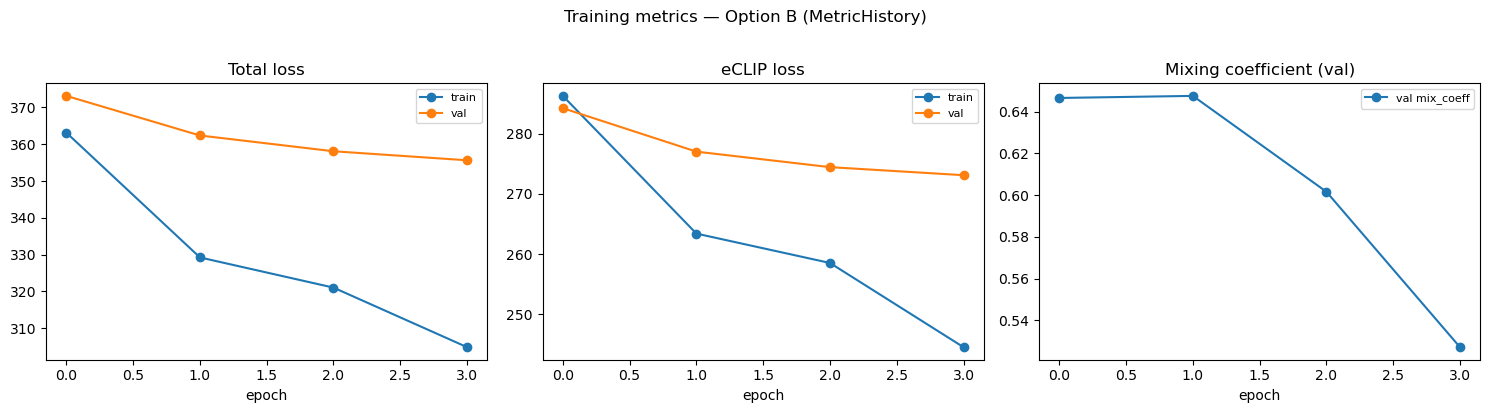

⏱ 0.46 s (00:00:00)


In [16]:
# In-memory loss curves from MetricHistory callback
# Available immediately after trainer.fit(); lost if kernel restarts.
import pandas as pd
import matplotlib.pyplot as plt

df_b = pd.DataFrame(metric_history.history)
df_b["epoch"] = range(len(df_b))

# train/* metrics have _epoch suffix (logged on_step+on_epoch → Lightning disambiguates)
# val/*   metrics have no suffix (logged on_epoch only)
plots = [
    ({"train": "train/loss_epoch", "val": "val/loss"}, "Total loss"),
    ({"train": "train/loss_eCLIP_epoch", "val": "val/loss_eCLIP"}, "eCLIP loss"),
    ({"val mix_coeff": "val/mix_coeff"}, "Mixing coefficient (val)"),
]

fig, axes = plt.subplots(1, len(plots), figsize=(15, 4))
for (col_dict, title), ax in zip(plots, axes):
    for label, col in col_dict.items():
        if col in df_b.columns:
            df_b.plot("epoch", col, ax=ax, label=label, marker="o")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Training metrics — Option B (MetricHistory)", y=1.02)
plt.tight_layout()
plt.show()

### Export the trained model

In [17]:
# Here : export as a statedict bundle, which is more lightweight than the full model checkpoint
# and can be loaded with load_parnet_model_from_statedict() without needing the full class definitions
output_model_path = FILEPATHS["output_dir"] / "model.statedict.pt"
save_parnet_model_as_statedict(
    lightning_model.model,
    output_model_path,
    pretrained_model_name,
)
logger.info(f"Saved fine-tuned model → {output_model_path}")

[14:59:25] INFO - Saved fine-tuned model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt
INFO:train_from_pretrained.py.ipynb:Saved fine-tuned model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt


⏱ 0.10 s (00:00:00)


In [18]:
# We can also export the full model checkpoint, which includes the full class definitions
# and can be loaded with load_parnet_model() but results in a larger file size.
output_model_path_full = FILEPATHS["output_dir"] / "model.full.pt"
torch.save(lightning_model.model, output_model_path_full)
logger.info(f"Saved full fine-tuned model → {output_model_path_full}")

[14:59:59] INFO - Saved full fine-tuned model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.full.pt
INFO:train_from_pretrained.py.ipynb:Saved full fine-tuned model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.full.pt


⏱ 0.13 s (00:00:00)


## Next step: evaluate

Open `evaluate_retrained_models.py.ipynb` and set `params_run_id` to
`"parnet.7m-0.0.ft-head.spliceosome-hepg2"` (or the value of
`params_name_of_resulting_model` from the Parameters cell above) to run
test-set evaluation and profile plots.